In [2]:
# %% ================================
# 0) Imports & Config
# ================================
from pathlib import Path
from datetime import datetime
from deltalake import DeltaTable
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [24]:
# train_rul.py
# -*- coding: utf-8 -*-
import os
import gc
import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from deltalake import DeltaTable
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ================================
# 1) Paths & utilidades
# ================================
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"

OUT_MODELS = BASE_DIR / "models"
OUT_REPORTS = BASE_DIR / "reports" / "modeling"
OUT_PRED = BASE_DIR / "data" / "predicciones"
for d in [OUT_MODELS, OUT_REPORTS, OUT_PRED]:
    d.mkdir(parents=True, exist_ok=True)

TIMESTAMP_COL = "timestamp"   # así guardaste en Delta (reset_index antes de write_deltalake)
RUL_MAX = 30.0                # tu horizon cap

# Etiquetas/columnas a excluir de X
LABEL_COLS = ["falla_30d", "estado_futuro", "rul_dias", "severidad_futura"]
TEXT_COLS  = ["variables_anomalas", "Descripcion_anomalia", "descripcion_anomalia"]

# ================================
# 2) Carga Gold desde Delta
# ================================
print("⚡ CARGA GOLD (Delta) PARA ENTRENAMIENTO RUL")
print("=" * 60)
print(f"📂 Ruta Delta (Gold complete): {RUTA_GOLD_COMPLETE}")

dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_gold = dt.to_pandas()
print(f"✅ Gold cargado: {df_gold.shape}")

# Asegurar timestamp como datetime y ordenar temporalmente
if TIMESTAMP_COL in df_gold.columns:
    df_gold[TIMESTAMP_COL] = pd.to_datetime(df_gold[TIMESTAMP_COL], utc=True, errors="coerce")
else:
    raise ValueError(f"No se encontró la columna '{TIMESTAMP_COL}' en la tabla Gold.")

df_gold = df_gold.sort_values(TIMESTAMP_COL).reset_index(drop=True)

print(f"📅 Período: {df_gold[TIMESTAMP_COL].min()} → {df_gold[TIMESTAMP_COL].max()}")
print(f"🧪 Columnas totales: {len(df_gold.columns)}")

# ================================
# 3) Preparar y dividir datos (split temporal 80/20)
# ================================
print("\n📅 División temporal 80/20 (train → primeras fechas, valid → últimas fechas)")
n = len(df_gold)
if n < 100:
    print("⚠️ Muy pocos registros para RUL; el modelo puede ser inestable.")

split_idx = int(n * 0.8)
df_train = df_gold.iloc[:split_idx].copy()
df_valid = df_gold.iloc[split_idx:].copy()

fecha_cut = df_valid[TIMESTAMP_COL].min() if len(df_valid) else None
print(f"   🟦 Train: {len(df_train):,} filas | {df_train[TIMESTAMP_COL].min()} → {df_train[TIMESTAMP_COL].max()}")
print(f"   🟧 Valid: {len(df_valid):,} filas | corte temporal = {fecha_cut}")

# ================================
# 4) Construir X, y para RUL
# ================================
def build_xy(df: pd.DataFrame):
    if "rul_dias" not in df.columns:
        raise ValueError("No se encontró la etiqueta 'rul_dias' en Gold.")
    y = df["rul_dias"].astype(float)

    drop_cols = [c for c in LABEL_COLS + TEXT_COLS + [TIMESTAMP_COL] if c in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore")

    # Solo numéricas para XGBoost
    X = X.select_dtypes(include=[np.number]).copy()

    # Imputación simple (si hay NaN): mediana columna a columna
    if X.isna().any().any():
        med = X.median(numeric_only=True)
        X = X.fillna(med)

    # Coherencia: recortar y (etiqueta) a [0, RUL_MAX]
    y = y.clip(lower=0.0, upper=RUL_MAX)

    return X, y

print("\n🧰 Preparando matrices X, y (solo numéricas; imputación mediana si aplica)")
X_train, y_train = build_xy(df_train)
X_valid, y_valid = build_xy(df_valid)

print(f"   ➤ X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   ➤ X_valid: {X_valid.shape} | y_valid: {y_valid.shape}")

# ================================
# 5) Entrenamiento XGBoostRegressor
# ================================
print("\n🤖 ENTRENAMIENTO — XGBoostRegressor (baseline RUL)")
model = XGBRegressor(
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42
)

model.fit(X_train, y_train)
print("✅ Modelo entrenado")

# ================================
# 6) Evaluación
# ================================
print("\n📏 EVALUACIÓN EN VALIDACIÓN")
pred_valid = model.predict(X_valid)
pred_valid = np.clip(pred_valid, 0.0, RUL_MAX)

mae = mean_absolute_error(y_valid, pred_valid)
rmse = mean_squared_error(y_valid, pred_valid)
print(f"   MAE (días):  {mae:.3f}")
print(f"   RMSE (días): {rmse:.3f}")

# MAE por buckets de interés
def bucketize(v):
    if v <= 7: return "≤7"
    if v <= 15: return "7–15"
    return ">15"

tmp = pd.DataFrame({"true": y_valid, "pred": pred_valid})
tmp["bucket_true"] = tmp["true"].apply(bucketize)
mae_buckets = tmp.groupby("bucket_true").apply(lambda d: mean_absolute_error(d["true"], d["pred"]))
print("\n   MAE por horizonte verdadero:")
for b, v in mae_buckets.items():
    print(f"   • {b}: {v:.3f} días")

# ================================
# 7) Guardado de modelo y predicciones
# ================================
ts = datetime.now().strftime("%Y%m%d_%H%M")
model_path = OUT_MODELS / f"xgb_rul_dias_{ts}.pkl"
joblib.dump({
    "model": model,
    "features": X_train.columns.tolist(),
    "label": "rul_dias",
    "clip_min": 0.0,
    "clip_max": RUL_MAX,
    "timestamp_col": TIMESTAMP_COL,
}, model_path)
print(f"\n💾 Modelo guardado: {model_path}")

pred_df = df_valid[[TIMESTAMP_COL]].copy()
pred_df["rul_true"] = y_valid.values
pred_df["rul_pred"] = pred_valid
pred_path = OUT_PRED / f"pred_rul_valid_{ts}.csv"
pred_df.to_csv(pred_path, index=False, encoding="utf-8")
print(f"📝 Predicciones de validación: {pred_path}")

# Reportito rápido (txt)
report_path = OUT_REPORTS / f"rul_eval_{ts}.txt"
with open(report_path, "w", encoding="utf-8") as f:
    w = f.write
    w("REPORTE RUL — Validación\n")
    w("="*40 + "\n\n")
    w(f"Gold: {RUTA_GOLD_COMPLETE}\n")
    w(f"Período: {df_gold[TIMESTAMP_COL].min()} → {df_gold[TIMESTAMP_COL].max()}\n")
    w(f"Split temporal: 80/20 | corte: {fecha_cut}\n\n")
    w(f"MAE (días): {mae:.4f}\n")
    w(f"RMSE (días): {rmse:.4f}\n\n")
    w("MAE por bucket verdadero:\n")
    for b, v in mae_buckets.items():
        w(f" - {b}: {v:.4f}\n")
    w("\nFeatures usadas (numéricas):\n")
    for c in X_train.columns:
        w(f" - {c}\n")

print(f"🗒️ Reporte guardado: {report_path}")

# Limpieza
del X_train, X_valid, y_train, y_valid, df_train, df_valid
gc.collect()
print("\n🎯 Entrenamiento RUL finalizado.\n")


⚡ CARGA GOLD (Delta) PARA ENTRENAMIENTO RUL
📂 Ruta Delta (Gold complete): C:\Users\Asus TUF\Desktop\proy_ml\data\capa_gold\features_transformador\features_complete
✅ Gold cargado: (8443, 71)
📅 Período: 2024-09-10 04:00:00+00:00 → 2025-08-27 22:00:00+00:00
🧪 Columnas totales: 71

📅 División temporal 80/20 (train → primeras fechas, valid → últimas fechas)
   🟦 Train: 6,754 filas | 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
   🟧 Valid: 1,689 filas | corte temporal = 2025-06-18 14:00:00+00:00

🧰 Preparando matrices X, y (solo numéricas; imputación mediana si aplica)
   ➤ X_train: (6754, 63) | y_train: (6754,)
   ➤ X_valid: (1689, 63) | y_valid: (1689,)

🤖 ENTRENAMIENTO — XGBoostRegressor (baseline RUL)
✅ Modelo entrenado

📏 EVALUACIÓN EN VALIDACIÓN
   MAE (días):  6.385
   RMSE (días): 127.602

   MAE por horizonte verdadero:
   • 7–15: 18.979 días
   • >15: 2.026 días
   • ≤7: 26.477 días

💾 Modelo guardado: C:\Users\Asus TUF\Desktop\proy_ml\models\xgb_rul_dias_20250910_0151.pk

C:\Users\Asus TUF\AppData\Local\Temp\ipykernel_21972\470583952.py:147: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mae_buckets = tmp.groupby("bucket_true").apply(lambda d: mean_absolute_error(d["true"], d["pred"]))



🎯 Entrenamiento RUL finalizado.



In [19]:
a=df['estado_futuro'].resample("7D")
a.value_counts()

AttributeError: 'DatetimeIndexResampler' object has no attribute 'value_counts'

✅ Gold cargado: (8443, 71)
⚠️ Drop constantes: ['suboptimal_operation']
🎯 Mapping: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}

== SPLIT INFO ==
Train rows: (6754, 58) | Valid rows: (1689, 58)
Train range: 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
Valid range: 2025-06-18 14:00:00+00:00 → 2025-08-27 22:00:00+00:00
Class dist (train): Counter({np.int64(2): 6754})
Class dist (valid): Counter({np.int64(2): 1329, np.int64(0): 192, np.int64(1): 168})

== SEQUENCES ==
Xtr_seq: (6731, 24, 58) | ytr_seq: (6731,)
Xva_seq: (1666, 24, 58) | yva_seq: (1666,)
⚠️ Train sequences have ONE class. Switching to BINARY fallback (NORMAL vs NO-NORMAL).
class_weight: {0: 3365.5, 1: 0.5}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 58)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 24, 58)    │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 24, 58)    │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 24)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 128)   │     95,744 │ masking_1[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 128)   │          0 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     49,408 │ dropout_2[0][0],  │
│                     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 145,217 (567.25 KB)

 Trainable params: 145,217 (567.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9421 - loss: 0.1049 - val_accuracy: 0.7839 - val_loss: 1.5809 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 1.0000 - loss: 2.5102e-04 - val_accuracy: 0.7839 - val_loss: 1.7310 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 1.4148e-04 - val_accuracy: 0.7839 - val_loss: 1.8206 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 1.0000 - loss: 9.7750e-05 - val_accuracy: 0.7839 - val_loss: 1.8873 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 1.0000 - loss: 7.4853e-05 - val_accuracy: 0.7839 - val_loss: 1.9381 - learning_rate: 0.0010
Epoch 6/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 1.0000 - loss: 6.4944e-05 - val_accuracy: 0.7839 - val_loss: 1.9607 - learning_rate: 5.0000e-04
Epoch 7/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 1.0000 

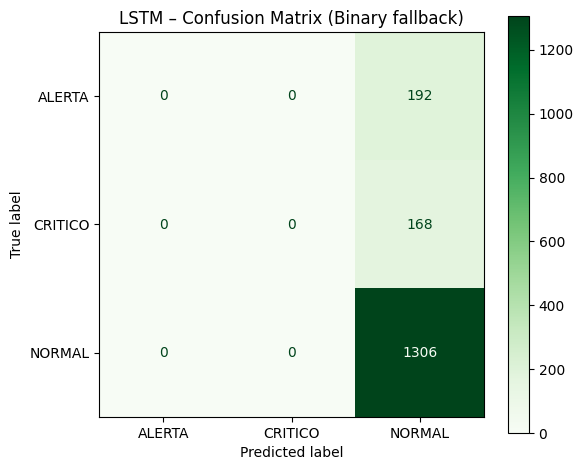


✅ Saved: C:\Users\Asus TUF\Desktop\proy_ml\capa_gold\artifacts_modelado_estado_futuro_lstm\lstm_estado_futuro.keras
Meta & scaler guardados en: C:\Users\Asus TUF\Desktop\proy_ml\capa_gold\artifacts_modelado_estado_futuro_lstm


In [20]:
# %% =========================================
# 0) Imports & config
# ============================================
import os
from pathlib import Path
from typing import List, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deltalake import DeltaTable
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 5)

# LSTM window setup
LOOKBACK = 24          # steps back (e.g., 24 horas si tu frecuencia es 1h)
HORIZON_SHIFT = 0      # 0 = predecir estado en t, 1 = predecir en t+1, etc.

# Paths
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"
ARTIFACTS_DIR = BASE_DIR / "capa_gold" / "artifacts_modelado_estado_futuro_lstm"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Columns to avoid (leak/text/future-derived)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro", "falla_30d", "rul_dias", "severidad_futura",
    "dias_proximo_evento", "proximidad_evento", "riesgo_acumulativo",
    "estado_operacional", "nivel_severidad", "variables_anomalas",
    "descripcion_anomalia"
]

# %% =========================================
# 1) Load Gold (Delta) & basic prep
# ============================================
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_gold = dt.to_pandas()
print("✅ Gold cargado:", df_gold.shape)

df = df_gold.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

TARGET = "estado_futuro"

# Keep numeric features (exclude leakage)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# Drop constant columns
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("⚠️ Drop constantes:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

# Optional: drop high-NaN cols (>30%)
nan_ratio = df[X_cols].isna().mean().sort_values(ascending=False)
high_nan_cols = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan_cols:
    print("⚠️ Drop >30% NaN:", high_nan_cols)
    X_cols = [c for c in X_cols if c not in high_nan_cols]

# Build X (fill NaN temporally-safe with median) & y
X_df = df[X_cols].replace([np.inf, -np.inf], np.nan).copy()
X_df = X_df.fillna(X_df.median(numeric_only=True))
y_raw = df[TARGET].astype(str).copy()  # as string for safety

# Encode target to ints (global)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
class_names = le.classes_.tolist()
print("🎯 Mapping:", dict(zip(class_names, range(len(class_names)))))

# %% =========================================
# 2) Temporal split (80/20) on rows, then sequence build
# ============================================
n = len(X_df)
cut = int(n * 0.80)  # keep pure temporal split; sequences will use past within each split

X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]
y_train_vec, y_valid_vec = y_enc[:cut], y_enc[cut:]
t_train_idx, t_valid_idx = X_train_df.index, X_valid_df.index

print("\n== SPLIT INFO ==")
print("Train rows:", X_train_df.shape, "| Valid rows:", X_valid_df.shape)
print("Train range:", t_train_idx.min(), "→", t_train_idx.max())
print("Valid range:", t_valid_idx.min(), "→", t_valid_idx.max())
print("Class dist (train):", Counter(y_train_vec))
print("Class dist (valid):", Counter(y_valid_vec))

# %% =========================================
# 3) Scale features (fit on train only)
# ============================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_df.values),
    index=X_train_df.index, columns=X_cols
)
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid_df.values),
    index=X_valid_df.index, columns=X_cols
)

# %% =========================================
# 4) Build sequences (sliding window)
#    Each sample = [t-LOOKBACK+1 ... t] → predict label at t+HORIZON_SHIFT
# ============================================
def make_sequences(X: pd.DataFrame, y: np.ndarray, lookback: int, horizon_shift: int) -> Tuple[np.ndarray, np.ndarray]:
    Xv = X.values
    yv = y
    N, F = Xv.shape
    seqs = []
    labels = []
    # last index we can take as "t" so that t + horizon_shift < N
    last_t = N - 1 - horizon_shift
    for t in range(lookback - 1, last_t + 1):
        start = t - (lookback - 1)
        end = t + 1
        seq = Xv[start:end]                    # shape (lookback, F)
        lab = yv[t + horizon_shift]           # int class at future step
        seqs.append(seq)
        labels.append(lab)
    return np.array(seqs, dtype=np.float32), np.array(labels, dtype=np.int32)

Xtr_seq, ytr_seq = make_sequences(X_train_scaled, y_train_vec, LOOKBACK, HORIZON_SHIFT)
Xva_seq, yva_seq = make_sequences(X_valid_scaled, y_valid_vec, LOOKBACK, HORIZON_SHIFT)

print("\n== SEQUENCES ==")
print("Xtr_seq:", Xtr_seq.shape, "| ytr_seq:", ytr_seq.shape)
print("Xva_seq:", Xva_seq.shape, "| yva_seq:", yva_seq.shape)

# %% =========================================
# 5) Handle class imbalance
#    - If only one class in train → binary fallback (NORMAL vs NO-NORMAL)
#    - Else compute class weights for multiclass
# ============================================
unique_train_classes = sorted(np.unique(ytr_seq).tolist())
multiclass_possible = len(unique_train_classes) >= 2

# Identify NORMAL id (if exists)
try:
    normal_id = int(np.where(le.classes_ == "NORMAL")[0][0])
except Exception:
    # fallback: majority class in train
    normal_id = Counter(ytr_seq).most_common(1)[0][0]

binary_mode = False
if not multiclass_possible:
    print("⚠️ Train sequences have ONE class. Switching to BINARY fallback (NORMAL vs NO-NORMAL).")
    binary_mode = True
    ytr_bin = (ytr_seq == normal_id).astype(int)
    yva_bin = (yva_seq == normal_id).astype(int)
    n_classes_out = 2
    # class weights for binary
    cnt = Counter(ytr_bin)
    total = len(ytr_bin)
    class_weight = {0: total / (2.0 * cnt.get(0, 1)), 1: total / (2.0 * cnt.get(1, 1))}
else:
    n_classes_out = len(le.classes_)
    cnt = Counter(ytr_seq)
    total = len(ytr_seq)
    # inverse frequency weights
    class_weight = {cls: total / (n_classes_out * cnt.get(cls, 1)) for cls in range(n_classes_out)}

print("class_weight:", class_weight)

# Prepare y tensors (one-hot if multiclass)
if binary_mode:
    ytr_out = ytr_bin
    yva_out = yva_bin
    final_activation = "sigmoid"
    loss_name = "binary_crossentropy"
    metrics_list = ["accuracy"]
else:
    ytr_out = tf.keras.utils.to_categorical(ytr_seq, num_classes=n_classes_out)
    yva_out = tf.keras.utils.to_categorical(yva_seq, num_classes=n_classes_out)
    final_activation = "softmax"
    loss_name = "categorical_crossentropy"
    metrics_list = ["accuracy"]

# %% =========================================
# 6) Build LSTM model
# ============================================
def build_lstm_model(n_steps: int, n_features: int, n_classes: int, final_activation: str) -> tf.keras.Model:
    inp = layers.Input(shape=(n_steps, n_features))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.2)(x)
    if final_activation == "sigmoid":
        out = layers.Dense(1, activation="sigmoid")(x)
    else:
        out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs=inp, outputs=out)
    return model

model = build_lstm_model(LOOKBACK, len(X_cols), n_classes_out, final_activation)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=loss_name, metrics=metrics_list)

model.summary()

# %% =========================================
# 7) Train (early stopping + lr schedule)
# ============================================
es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)

history = model.fit(
    Xtr_seq, ytr_out,
    validation_data=(Xva_seq, yva_out),
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[es, rlr],
    verbose=1
)

# %% =========================================
# 8) Evaluation & confusion matrix
# ============================================
if binary_mode:
    # predict probs → threshold 0.5 (puedes ajustar para priorizar NO-NORMAL)
    p_va = model.predict(Xva_seq).ravel()
    y_pred_bin = (p_va >= 0.5).astype(int)

    # map back to global ids for report
    non_norm_ids = sorted(set(range(len(le.classes_))) - {normal_id})
    non_norm_id = non_norm_ids[0] if len(non_norm_ids) else normal_id
    y_pred_global = np.where(y_pred_bin == 1, normal_id, non_norm_id)
    y_true_global = yva_seq  # originales

    print("\n=== LSTM (Binary NORMAL vs NO-NORMAL) ===")
    print(classification_report(
        y_true_global, y_pred_global,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_.tolist(),
        digits=4, zero_division=0
    ))
    cm = confusion_matrix(y_true_global, y_pred_global, labels=np.arange(len(le.classes_)))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.tolist()).plot(cmap="Greens")
    plt.title("LSTM – Confusion Matrix (Binary fallback)")
    plt.tight_layout()
    plt.show()
else:
    p_va = model.predict(Xva_seq)  # shape (N, C)
    y_pred = p_va.argmax(axis=1)

    print("\n=== LSTM (Multiclass) ===")
    print(classification_report(
        yva_seq, y_pred,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_.tolist(),
        digits=4, zero_division=0
    ))
    cm = confusion_matrix(yva_seq, y_pred, labels=np.arange(len(le.classes_)))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.tolist()).plot(cmap="Blues")
    plt.title("LSTM – Confusion Matrix")
    plt.tight_layout()
    plt.show()

# %% =========================================
# 9) Save artifacts (model, scaler, meta)
# ============================================
model_path = ARTIFACTS_DIR / "lstm_estado_futuro.keras"
model.save(model_path)
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)

import joblib, json
joblib.dump(scaler, ARTIFACTS_DIR / "scaler.pkl")
meta = {
    "lookback": LOOKBACK,
    "horizon_shift": HORIZON_SHIFT,
    "classes": class_names,
    "binary_mode": binary_mode,
    "normal_id": int(normal_id),
}
with open(ARTIFACTS_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"\n✅ Saved: {model_path}")
print("Meta & scaler guardados en:", ARTIFACTS_DIR)


✅ Gold cargado: (8443, 71)
⚠️ Drop constantes: ['suboptimal_operation']
🎯 Mapping: {'ALERTA': 0, 'CRITICO': 1, 'NORMAL': 2}

== SPLIT INFO ==
Train rows: (6754, 58) | Valid rows: (1689, 58)
Train range: 2024-09-10 04:00:00+00:00 → 2025-06-18 13:00:00+00:00
Valid range: 2025-06-18 14:00:00+00:00 → 2025-08-27 22:00:00+00:00
Class dist (train): Counter({np.int64(2): 6754})
Class dist (valid): Counter({np.int64(2): 1329, np.int64(0): 192, np.int64(1): 168})

== SEQUENCES ==
Xtr_seq: (6731, 24, 58) | ytr_seq: (6731,)
Xva_seq: (1666, 24, 58) | yva_seq: (1666,)
⚠️ Train sequences have ONE class. Switching to BINARY fallback (NORMAL vs NO-NORMAL).
class_weight: {0: 3365.5, 1: 0.5}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 58)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 24, 58)    │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_2 (Masking) │ (None, 24, 58)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_2 (Any)         │ (None, 24)        │          0 │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 24, 128)   │     95,744 │ masking_2[0][0],  │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 24, 128)   │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ (None, 64)        │     49,408 │ dropout_4[0][0],  │
│                     │                   │            │ any_2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ lstm_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 145,217 (567.25 KB)

 Trainable params: 145,217 (567.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9251 - loss: 0.1068 - val_accuracy: 0.7839 - val_loss: 1.6690 - learning_rate: 0.0010
Epoch 2/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 1.5186e-04 - val_accuracy: 0.7839 - val_loss: 1.8267 - learning_rate: 0.0010
Epoch 3/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 8.1577e-05 - val_accuracy: 0.7839 - val_loss: 1.9250 - learning_rate: 0.0010
Epoch 4/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 5.2183e-05 - val_accuracy: 0.7839 - val_loss: 2.0023 - learning_rate: 0.0010
Epoch 5/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 3.6685e-05 - val_accuracy: 0.7839 - val_loss: 2.0658 - learning_rate: 0.0010
Epoch 6/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 2.8902e-05 - val_accuracy: 0.7839 - val_loss: 2.0932 - learning_rate: 5.0000e-04
Epoch 7/60
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 

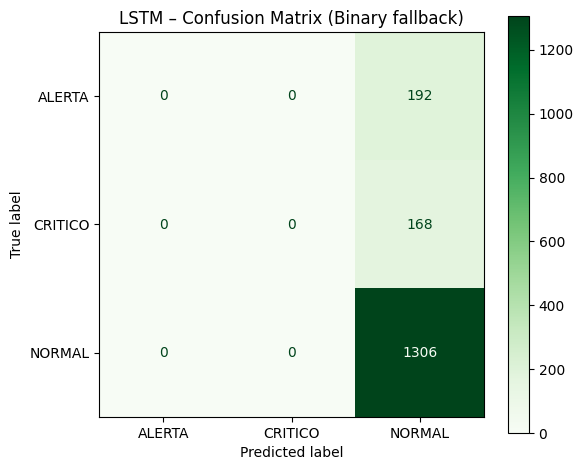


✅ Saved: C:\Users\Asus TUF\Desktop\proy_ml\capa_gold\artifacts_modelado_estado_futuro_lstm\lstm_estado_futuro.keras
Meta & scaler guardados en: C:\Users\Asus TUF\Desktop\proy_ml\capa_gold\artifacts_modelado_estado_futuro_lstm


In [21]:
# %% =========================================
# 0) Imports & config
# ============================================
import os
from pathlib import Path
from typing import List, Tuple
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from deltalake import DeltaTable
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (6, 5)

# LSTM window setup
LOOKBACK = 24          # steps back (e.g., 24 horas si tu frecuencia es 1h)
HORIZON_SHIFT = 0      # 0 = predecir estado en t, 1 = predecir en t+1, etc.

# Paths
def find_repo_root() -> Path:
    p = Path.cwd().resolve()
    for cand in (p, *p.parents):
        if (cand / "data").exists():
            return cand
    return p

BASE_DIR = find_repo_root()
RUTA_GOLD_COMPLETE = BASE_DIR / "data" / "capa_gold" / "features_transformador" / "features_complete"
ARTIFACTS_DIR = BASE_DIR / "capa_gold" / "artifacts_modelado_estado_futuro_lstm"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Columns to avoid (leak/text/future-derived)
LEAK_OR_TEXT_COLS: List[str] = [
    "estado_futuro", "falla_30d", "rul_dias", "severidad_futura",
    "dias_proximo_evento", "proximidad_evento", "riesgo_acumulativo",
    "estado_operacional", "nivel_severidad", "variables_anomalas",
    "descripcion_anomalia"
]

# %% =========================================
# 1) Load Gold (Delta) & basic prep
# ============================================
dt = DeltaTable(str(RUTA_GOLD_COMPLETE))
df_gold = dt.to_pandas()
print("✅ Gold cargado:", df_gold.shape)

df = df_gold.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
df = df.sort_values("timestamp").set_index("timestamp")

TARGET = "estado_futuro"

# Keep numeric features (exclude leakage)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in numeric_cols if c not in LEAK_OR_TEXT_COLS]

# Drop constant columns
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("⚠️ Drop constantes:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

# Optional: drop high-NaN cols (>30%)
nan_ratio = df[X_cols].isna().mean().sort_values(ascending=False)
high_nan_cols = nan_ratio[nan_ratio > 0.30].index.tolist()
if high_nan_cols:
    print("⚠️ Drop >30% NaN:", high_nan_cols)
    X_cols = [c for c in X_cols if c not in high_nan_cols]

# Build X (fill NaN temporally-safe with median) & y
X_df = df[X_cols].replace([np.inf, -np.inf], np.nan).copy()
X_df = X_df.fillna(X_df.median(numeric_only=True))
y_raw = df[TARGET].astype(str).copy()  # as string for safety

# Encode target to ints (global)
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
class_names = le.classes_.tolist()
print("🎯 Mapping:", dict(zip(class_names, range(len(class_names)))))

# %% =========================================
# 2) Temporal split (80/20) on rows, then sequence build
# ============================================
n = len(X_df)
cut = int(n * 0.80)  # keep pure temporal split; sequences will use past within each split

X_train_df, X_valid_df = X_df.iloc[:cut], X_df.iloc[cut:]
y_train_vec, y_valid_vec = y_enc[:cut], y_enc[cut:]
t_train_idx, t_valid_idx = X_train_df.index, X_valid_df.index

print("\n== SPLIT INFO ==")
print("Train rows:", X_train_df.shape, "| Valid rows:", X_valid_df.shape)
print("Train range:", t_train_idx.min(), "→", t_train_idx.max())
print("Valid range:", t_valid_idx.min(), "→", t_valid_idx.max())
print("Class dist (train):", Counter(y_train_vec))
print("Class dist (valid):", Counter(y_valid_vec))

# %% =========================================
# 3) Scale features (fit on train only)
# ============================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_df.values),
    index=X_train_df.index, columns=X_cols
)
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid_df.values),
    index=X_valid_df.index, columns=X_cols
)

# %% =========================================
# 4) Build sequences (sliding window)
#    Each sample = [t-LOOKBACK+1 ... t] → predict label at t+HORIZON_SHIFT
# ============================================
def make_sequences(X: pd.DataFrame, y: np.ndarray, lookback: int, horizon_shift: int) -> Tuple[np.ndarray, np.ndarray]:
    Xv = X.values
    yv = y
    N, F = Xv.shape
    seqs = []
    labels = []
    # last index we can take as "t" so that t + horizon_shift < N
    last_t = N - 1 - horizon_shift
    for t in range(lookback - 1, last_t + 1):
        start = t - (lookback - 1)
        end = t + 1
        seq = Xv[start:end]                    # shape (lookback, F)
        lab = yv[t + horizon_shift]           # int class at future step
        seqs.append(seq)
        labels.append(lab)
    return np.array(seqs, dtype=np.float32), np.array(labels, dtype=np.int32)

Xtr_seq, ytr_seq = make_sequences(X_train_scaled, y_train_vec, LOOKBACK, HORIZON_SHIFT)
Xva_seq, yva_seq = make_sequences(X_valid_scaled, y_valid_vec, LOOKBACK, HORIZON_SHIFT)

print("\n== SEQUENCES ==")
print("Xtr_seq:", Xtr_seq.shape, "| ytr_seq:", ytr_seq.shape)
print("Xva_seq:", Xva_seq.shape, "| yva_seq:", yva_seq.shape)

# %% =========================================
# 5) Handle class imbalance
#    - If only one class in train → binary fallback (NORMAL vs NO-NORMAL)
#    - Else compute class weights for multiclass
# ============================================
unique_train_classes = sorted(np.unique(ytr_seq).tolist())
multiclass_possible = len(unique_train_classes) >= 2

# Identify NORMAL id (if exists)
try:
    normal_id = int(np.where(le.classes_ == "NORMAL")[0][0])
except Exception:
    # fallback: majority class in train
    normal_id = Counter(ytr_seq).most_common(1)[0][0]

binary_mode = False
if not multiclass_possible:
    print("⚠️ Train sequences have ONE class. Switching to BINARY fallback (NORMAL vs NO-NORMAL).")
    binary_mode = True
    ytr_bin = (ytr_seq == normal_id).astype(int)
    yva_bin = (yva_seq == normal_id).astype(int)
    n_classes_out = 2
    # class weights for binary
    cnt = Counter(ytr_bin)
    total = len(ytr_bin)
    class_weight = {0: total / (2.0 * cnt.get(0, 1)), 1: total / (2.0 * cnt.get(1, 1))}
else:
    n_classes_out = len(le.classes_)
    cnt = Counter(ytr_seq)
    total = len(ytr_seq)
    # inverse frequency weights
    class_weight = {cls: total / (n_classes_out * cnt.get(cls, 1)) for cls in range(n_classes_out)}

print("class_weight:", class_weight)

# Prepare y tensors (one-hot if multiclass)
if binary_mode:
    ytr_out = ytr_bin
    yva_out = yva_bin
    final_activation = "sigmoid"
    loss_name = "binary_crossentropy"
    metrics_list = ["accuracy"]
else:
    ytr_out = tf.keras.utils.to_categorical(ytr_seq, num_classes=n_classes_out)
    yva_out = tf.keras.utils.to_categorical(yva_seq, num_classes=n_classes_out)
    final_activation = "softmax"
    loss_name = "categorical_crossentropy"
    metrics_list = ["accuracy"]

# %% =========================================
# 6) Build LSTM model
# ============================================
def build_lstm_model(n_steps: int, n_features: int, n_classes: int, final_activation: str) -> tf.keras.Model:
    inp = layers.Input(shape=(n_steps, n_features))
    x = layers.Masking()(inp)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.2)(x)
    if final_activation == "sigmoid":
        out = layers.Dense(1, activation="sigmoid")(x)
    else:
        out = layers.Dense(n_classes, activation="softmax")(x)
    model = models.Model(inputs=inp, outputs=out)
    return model

model = build_lstm_model(LOOKBACK, len(X_cols), n_classes_out, final_activation)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=loss_name, metrics=metrics_list)

model.summary()

# %% =========================================
# 7) Train (early stopping + lr schedule)
# ============================================
es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5)

history = model.fit(
    Xtr_seq, ytr_out,
    validation_data=(Xva_seq, yva_out),
    epochs=60,
    batch_size=128,
    class_weight=class_weight,
    callbacks=[es, rlr],
    verbose=1
)

# %% =========================================
# 8) Evaluation & confusion matrix
# ============================================
if binary_mode:
    # predict probs → threshold 0.5 (puedes ajustar para priorizar NO-NORMAL)
    p_va = model.predict(Xva_seq).ravel()
    y_pred_bin = (p_va >= 0.5).astype(int)

    # map back to global ids for report
    non_norm_ids = sorted(set(range(len(le.classes_))) - {normal_id})
    non_norm_id = non_norm_ids[0] if len(non_norm_ids) else normal_id
    y_pred_global = np.where(y_pred_bin == 1, normal_id, non_norm_id)
    y_true_global = yva_seq  # originales

    print("\n=== LSTM (Binary NORMAL vs NO-NORMAL) ===")
    print(classification_report(
        y_true_global, y_pred_global,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_.tolist(),
        digits=4, zero_division=0
    ))
    cm = confusion_matrix(y_true_global, y_pred_global, labels=np.arange(len(le.classes_)))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.tolist()).plot(cmap="Greens")
    plt.title("LSTM – Confusion Matrix (Binary fallback)")
    plt.tight_layout()
    plt.show()
else:
    p_va = model.predict(Xva_seq)  # shape (N, C)
    y_pred = p_va.argmax(axis=1)

    print("\n=== LSTM (Multiclass) ===")
    print(classification_report(
        yva_seq, y_pred,
        labels=np.arange(len(le.classes_)),
        target_names=le.classes_.tolist(),
        digits=4, zero_division=0
    ))
    cm = confusion_matrix(yva_seq, y_pred, labels=np.arange(len(le.classes_)))
    ConfusionMatrixDisplay(cm, display_labels=le.classes_.tolist()).plot(cmap="Blues")
    plt.title("LSTM – Confusion Matrix")
    plt.tight_layout()
    plt.show()

# %% =========================================
# 9) Save artifacts (model, scaler, meta)
# ============================================
model_path = ARTIFACTS_DIR / "lstm_estado_futuro.keras"
model.save(model_path)
pd.Series(X_cols).to_csv(ARTIFACTS_DIR / "feature_columns.csv", index=False)

import joblib, json
joblib.dump(scaler, ARTIFACTS_DIR / "scaler.pkl")
meta = {
    "lookback": LOOKBACK,
    "horizon_shift": HORIZON_SHIFT,
    "classes": class_names,
    "binary_mode": binary_mode,
    "normal_id": int(normal_id),
}
with open(ARTIFACTS_DIR / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f"\n✅ Saved: {model_path}")
print("Meta & scaler guardados en:", ARTIFACTS_DIR)
